In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### Regresión Líneal

La regresión lineal es una técnica estadística utilizada para modelar la relación entre una variable dependiente y una o más variables independientes. La idea principal es encontrar la línea recta que mejor se ajuste a los datos, lo que se logra minimizando la suma de los errores cuadráticos entre las observaciones y las predicciones del modelo.

La fórmula matemática de la regresión lineal  es:

$$ Y = \beta_0 + \beta X + \epsilon $$

donde $Y$ es la variable dependiente, $X$ es la matriz de diseño, $\beta_0$ es el intercepto, $\beta$ es el vector de coeficientes que conecta $Y$ con cada una de las variables en $X$ y $\epsilon$ es el error aleatorio.

Por el momento nos enfocaremos en ajustar un modelo con una sola variable x. A este modelo se le llama regresión lineal simple y está representado como sigue:

$$ Y = \beta_0 + \beta_1 X_1 + \epsilon $$

Como un primer ejemplo estudiaremos uno de los primeros casos ( o el primer caso ) en el que se usó la regresión lineal simple.


En la década de 1870,Francis Galton,uno de los pioneros en la aplicación de la regresión lineal, investigó la relación entre la estatura de padres e hijos. Desarrolló el concepto de regresión hacia la media y propuso un método para ajustar una línea a los datos que minimiza la suma de los cuadrados de las diferencias verticales entre los puntos de datos y la línea de regresión. Él buscaba explicar el fenómeno de que los hijos de padres altos, tienden a ser altos en su generación, pero no tan altos como lo fueron sus padres en la propia, por lo que hay un efecto de "regresión"

El término "regresión" fue introducido formalmente más tarde por el estadístico Karl Pearson en la primera mitad del siglo XX. Pearson y su colaborador, Udny Yule, hicieron importantes contribuciones al desarrollo de la regresión lineal y sentaron las bases matemáticas y estadísticas para el modelo.

In [2]:
df = pd.read_excel("Estaturas.xlsx") 
### Cargamos el dataset "Estaturas" este contiene 100 registros en los que se tienela estatura de padre e hijo

In [3]:
df.shape ## consultamos dimensión del df

(100, 2)

In [5]:
df.head(5) # vemos el encabezado del df

,ESTATURA PADRE,ESTATURA HIJO
0,191,190
1,171,166
2,153,149
3,189,186
4,187,185


In [5]:
df.dtypes # consultamos el tipo de datos del df

ESTATURA PADRE    int64
ESTATURA HIJO     int64
dtype: object

In [6]:
df.isna().sum() # vemos si tenemos valores nulos en el df

ESTATURA PADRE    0
ESTATURA HIJO     0
dtype: int64

Notamos que parece haber una relación lineal entre ambas variables (si el padre es alto, el hijo será alto. si el padre es bajo el hijo es bajo

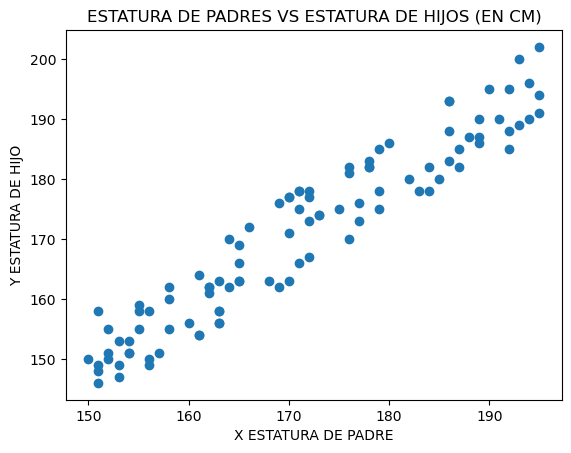

In [7]:
plt.scatter(df["ESTATURA PADRE"],df["ESTATURA HIJO"])
plt.xlabel("X ESTATURA DE PADRE")
plt.ylabel("Y ESTATURA DE HIJO")
plt.title("ESTATURA DE PADRES VS ESTATURA DE HIJOS (EN CM)")
plt.show()

Podríamos utilizar varias rectas que expliquen este caso.Pero... Cuál sería la mejor recta en este caso? Cuales serían los coeficientes optimos?

<img src="RECTAS REGLIN.png">

Para encontrar los coeficientes optimos Utilizaremos el método de míınimos cuadrados, que consiste en minimizar la suma de los errores al cuadrado.





El objetivo es encontrar los valores de 
$ \beta_1 $ y $ \beta_0 $

que minimizan la suma de los errores al cuadrado entre las predicciones y los valores reales. La fórmula de la suma de los errores cuadrados (SSE) es:

$$ \ SSE = \sum_{i=1}^{n} (y_i - (\beta_1x_i + \beta_0))^2 \ $$

donde:
- $  n  $ es el número de observaciones,
- $  (x_i, y_i)  $ son los puntos de datos.

PREGUNTA: ¿Por qué elevamos los errores al cuadrado y no sacamos su valor absoluto?
### Proceso de Mínimos Cuadrados

1. Calcular las derivadas parciales de SSE con respecto a $ \beta_1 $ y $ \beta_0 $
2. Igualar las derivadas a cero para encontrar los valores críticos.
3. Resolver las ecuaciones resultantes para obtener los valores óptimos de $ \beta_1 $ y $ \beta_0 $
4. La línea ajustada tiene la forma $$  y = \hat{\beta_1}x + \hat{\beta_0}  $$
donde $ \hat{\beta_1} $  y  $ \hat{\beta_0} $ son los valores óptimos y se expresan como sigue:

$$ \hat{\beta}_1 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}  $$

$$  \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x} $$


donde:
- $ n $ es el número de observaciones,
- $ (x_i, y_i) $ son los puntos de datos,
- $ \bar{x} $ es la media de $ x $,
- $ \bar{y} $ es la media de $ y $.


### Interpretación

- $ \hat{\beta}_1 $ mide el cambio promedio en \(y\) por unidad de cambio en \(x\). (geometricamente es la pendiente de la recta)
- $ \hat{\beta}_0 $ es la estimación del valor de \(y\) cuando \(x\) es igual a cero. (geometricamente es la ordenada al origen)

Este método proporciona una forma sistemática de encontrar la línea que mejor se ajusta a los datos, minimizando la discrepancia entre las predicciones y los valores reales.

Es importante notar que $ \beta_1 $ y $ \beta_0 $ son $ parametros $ del modelo y su valor depende de los valores de nuestra muestra de datos

### SOLUCION USANDO SKLEARN

In [9]:
X=np.array(df["ESTATURA PADRE"]).reshape(-1,1)
Y=df["ESTATURA HIJO"]

In [10]:
model = LinearRegression(fit_intercept=True).fit(X, Y) ## podemos decidir si ajustar el intercepto del modelo

In [11]:
# Imprimimos los coeficientes del modelo
print('Beta 0:', model.intercept_)
print('Beta 1', model.coef_)

Beta 0: -6.212729209781514
Beta 1 [1.03449468]


In [12]:
df.head(1)

,ESTATURA PADRE,ESTATURA HIJO
0,191,190


In [13]:
prediccion = model.predict([[191]])
print('Estatura de un hijo con padre de estatura 191:',prediccion)

Estatura de un hijo con padre de estatura 191: [191.37575419]


### SOLUCION MANUAL

<img src="ESTIMADORES_REGLIN.png">

In [14]:
def reglin_simple(X,Y):
    X=np.array(X)
    Y=np.array(Y)
    b1 = sum((X-X.mean()) * (Y-Y.mean())) / sum((X-X.mean())**2)
    bo = Y.mean() - b1*(X.mean())
    return (bo,b1)

In [15]:
bo = reglin_simple(df["ESTATURA PADRE"],df["ESTATURA HIJO"])[0]
b1 = reglin_simple(df["ESTATURA PADRE"],df["ESTATURA HIJO"])[1]
print("b1: ",b1)
print("bo: ",bo)

b1:  1.0344946774765158
bo:  -6.212729209781372


In [16]:
def predict_reglin_simple(bo,b1,x1):
    return bo + (b1*x1)

In [17]:
predict_reglin_simple(bo,b1,191)

191.37575418823315

In [18]:
prediccion = bo + b1*(X)

In [19]:
df["PREDICCION"]=prediccion

In [20]:
df

,ESTATURA PADRE,ESTATURA HIJO,PREDICCION
0,191,190,191.375754
1,171,166,170.685861
2,153,149,152.064956
3,189,186,189.306765
4,187,185,187.237775
...,...,...,...
95,161,164,160.340914
96,193,200,193.444744
97,169,176,168.616871
98,156,150,155.168440


### Visualización de los datos reales con el modelo estimado por minimos cuadrados

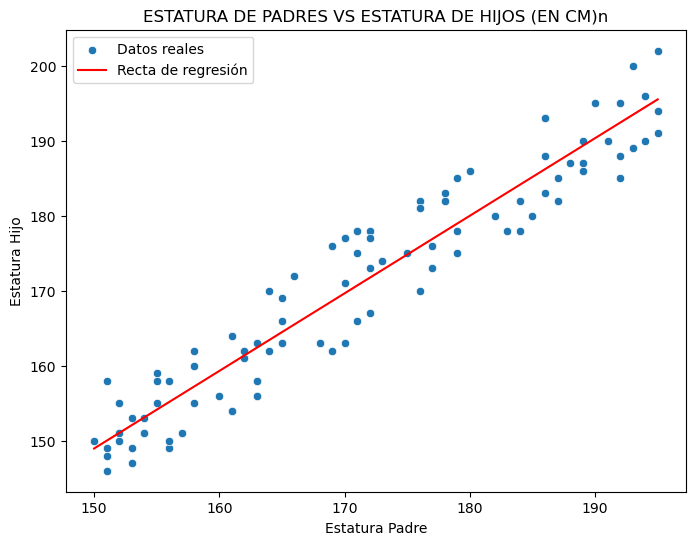

In [21]:
# Crear el gráfico de dispersión
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ESTATURA PADRE', y='ESTATURA HIJO', data=df, label='Datos reales')

# Añadir la recta de regresión
regression_model = LinearRegression()
regression_model.fit(df[['ESTATURA PADRE']], df['ESTATURA HIJO'])
predicted_values = regression_model.predict(df[['ESTATURA PADRE']])
sns.lineplot(x=df['ESTATURA PADRE'], y=predicted_values, color='red', label='Recta de regresión')

# Añadir etiquetas y leyenda
plt.title('ESTATURA DE PADRES VS ESTATURA DE HIJOS (EN CM)n')
plt.xlabel('Estatura Padre')
plt.ylabel('Estatura Hijo')
plt.legend()

# Mostrar el gráfico
plt.show()

In [22]:
### probando otros modelos
b1s=[1.0344946774765158,1.04,1.05,1.06,1.07,1.02]
bos=[-6.212729209781514,-6.5,-6.8,-7,-8,-6]
errores=[]
for i in range(len(bos)):
    errores.append(sum((np.array(df["ESTATURA HIJO"]) - (bos[i] + (b1s[i]*np.array(df["ESTATURA PADRE"]))))**2))
errores ## el primero es el que obtuvimos por minimos cuadrados

[1951.6335170220125,
 1995.0639999999999,
 2382.8649999999984,
 3243.1640000000084,
 3813.721000000007,
 2469.675999999998]

### interpretacion
En el contexto de una regresion lineal donde Y representa la estatura del hijo y X la estatura del padre

$ \beta_0 $:es el intercepto de la línea de regresión. En este caso, si la estatura del padre $ x_i $ es cero, entonces el modelo predice que la estatura del hijo $ y_i $ sería de -6.21 cm menor. Sin embargo, en el contexto de la estatura, esta interpretación puede no tener un significado práctico, ya que no tiene sentido que la estatura del padre sea cero.

$ \beta_1 $ :es la pendiente de la línea de regresión la interpretación sería que, en promedio, por cada unidad adicional de estatura del padre $ x_i $, la estatura del hijo $ y_i $ aumenta aproximadamente 
1.03 cm. Esto implica que hay una relación positiva entre la estatura del padre y la estatura del hijo


En resumen, el modelo de regresión lineal sugiere que, en promedio, la estatura del hijo aumenta en aproximadamente 
1.03  unidades por cada unidad adicional de estatura del padre. El intercepto $ \beta_0 $
proporciona un punto de partida teórico, pero en el contexto de la estatura, su interpretación práctica puede no ser relevante. Es común que el intercepto tenga un significado limitado o nulo en situaciones del mundo real.

###### Regresamos a presentación

### UTILIZANDO CONJUNTO DE PRUEBA Y ENTRENAMIENTO

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X=np.array(df["ESTATURA PADRE"]).reshape(-1,1)
Y=df["ESTATURA HIJO"]

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state=0)

In [31]:
model = LinearRegression(fit_intercept=True).fit(X_train, Y_train)

In [32]:
# Imprimimos los coeficientes del modelo
print('Beta 0:', model.intercept_)
print('Beta 1', model.coef_)
# Los coeficientes son parecidos a los del primero modelo, pero no iguales

Beta 0: -4.610755255250581
Beta 1 [1.02563112]


Utilizaremos el conjunto de prueba para evaluar los resultados del modelo

In [33]:
y_pred = model.predict(X_test)

In [34]:
model.predict([[158]])

array([157.43896184])

In [35]:
model.predict([[170]])

array([169.74653529])